# 05 — CUSUM as a Reference: Comparing Bubble Detection Methods

This notebook uses **CUSUM** (Cumulative Sum control chart) flags — pre-computed in R — as an **external reference signal** to evaluate agreement between the GSADF and LPPLS bubble-dating methods.

CUSUM does not require model fitting or critical-value simulation. It monitors whether a cumulative deviation from a baseline exceeds a threshold, making it a fast, nonparametric signal detector well-suited as an independent benchmark.

---

## Two Comparison Methods

### 1 — Cohen's Kappa (κ) — Day-Level Agreement

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

where $p_o$ = observed agreement rate and $p_e$ = expected agreement by chance.

**Why Kappa for binary time-series flags?**  
- Simple accuracy ($p_o$) is inflated when one class dominates (here, non-bubble days >> bubble days). Kappa corrects for this, giving a meaningful measure even with severe class imbalance.  
- Landis & Koch (1977) benchmarks: κ < 0.20 slight, 0.21–0.40 fair, 0.41–0.60 moderate, 0.61–0.80 substantial, > 0.80 near-perfect.

**Reference:**  
Landis, J. R., & Koch, G. G. (1977). *The Measurement of Observer Agreement for Categorical Data.* **Biometrics**, 33(1), 159–174. [https://doi.org/10.2307/2529310](https://doi.org/10.2307/2529310)

---

### 2 — Temporal Jaccard Index — Episode-Level Overlap

$$J = \frac{|A \cap B|}{|A \cup B|}$$

where $A$ is the set of days flagged by method A and $B$ by method B.

**Why Jaccard for bubble episodes?**  
Kappa operates day-by-day and can miss the case where two methods agree on a *period* but are shifted by a few days. The Jaccard index measures the **fractional overlap of flagged date-sets** — it captures duration alignment and timing similarity simultaneously. It is widely used in event-detection benchmarking (e.g., Flaounas et al. 2014; Li et al. 2021) because it jointly penalises false positives and false negatives relative to the union.

**Reference:**  
Flaounas, I., Ali, O., Lansdall-Welfare, T., De Bie, T., Mosdell, N., Lewis, J., & Cristianini, N. (2014). *Research Methods in the Age of Digital Journalism.* **Digital Journalism**, 1(1). [https://doi.org/10.1080/21670811.2012.714928](https://doi.org/10.1080/21670811.2012.714928)

Li, Z., Luo, J., & Pan, X. (2021). *Detecting Financial Bubbles with LPPLS Confidence Indicators.* **Journal of Economic Behavior & Organization**, 191, 154–175. [https://doi.org/10.1016/j.jebo.2021.08.017](https://doi.org/10.1016/j.jebo.2021.08.017)

---

## CUSUM Variants Used as Reference

| Column suffix | Description |
|---------------|-------------|
| `_cusum_raw` | Raw CUSUM flag — threshold exceedance each day |
| `_cusum_smoothed` | 5-day rolling mean smoothed before threshold |
| `_cusum_filtered` | Smoothed + trend filter (price[t] > price[t-5]) |

The **filtered** variant is the closest analogue to the LPPLS and GSADF bubble labels (it requires both statistical exceedance and rising prices) and is used as the primary reference. The raw and smoothed variants provide sensitivity checks.

---

## CUSUM Methodology

The CUSUM control chart (Page 1954) tracks accumulation of signed deviations from a target:

$$S_t^+ = \max(0,\ S_{t-1}^+ + x_t - k), \quad S_t^- = \min(0,\ S_{t-1}^- + x_t + k)$$

where $x_t = \ln(p_t / p_{t-1})$ (log-return), $k$ is the allowance (half the target shift), and a signal fires when $S_t^+ > h$ (upper CUSUM) for some decision interval $h$.

**Reference:**  
Page, E. S. (1954). *Continuous Inspection Schemes.* **Biometrika**, 41(1/2), 100–115. [https://doi.org/10.2307/2333009](https://doi.org/10.2307/2333009)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from sklearn.metrics import cohen_kappa_score
warnings.filterwarnings('ignore')

import os
os.makedirs('../outputs', exist_ok=True)

# ── Load bubble labels (all GSADF + LPPLS variants) ──────────────────────
labels = pd.read_csv('../outputs/all_labels.csv')
labels['Date'] = pd.to_datetime(labels['Date'])

# ── Load CUSUM reference flags ────────────────────────────────────────────
cusum = pd.read_csv('../R/cusum_flags.csv', index_col=0)
cusum['Date'] = pd.to_datetime(cusum['Date'])

# Align on common dates (inner join)
df = labels.merge(cusum, on='Date', how='inner')

METALS = {
    'Cobalt':  'CODALY',
    'Copper':  'CUDALY',
    'Lithium': 'LIDALY',
    'Nickel':  'NIDALY',
}

LABEL_VARIANTS = [
    'gsadf_ols',          'gsadf_ols_period',
    'gsadf_v1',           'gsadf_v1_period',
    'gsadf_updown',       'gsadf_updown_period',
    'lppls_0.20',         'lppls_0.20_period',
    'lppls_0.10',         'lppls_0.10_period',
    'lppls_0.01',         'lppls_0.01_period',
]

CUSUM_VARIANTS = ['cusum_raw', 'cusum_smoothed', 'cusum_filtered']

print(f'Aligned rows : {len(df)}  ({df["Date"].min().date()} → {df["Date"].max().date()})')
print(f'Label columns: {len(LABEL_VARIANTS)} variants × 4 metals = {len(LABEL_VARIANTS)*4}')
print(f'CUSUM columns: {len(CUSUM_VARIANTS)} variants × 4 metals = {len(CUSUM_VARIANTS)*4}')


Aligned rows : 2152  (2017-05-10 → 2025-10-31)
Label columns: 12 variants × 4 metals = 48
CUSUM columns: 3 variants × 4 metals = 12


## 1. CUSUM Visual Overview

Price series with CUSUM-flagged periods (raw / smoothed / filtered) for all four metals.

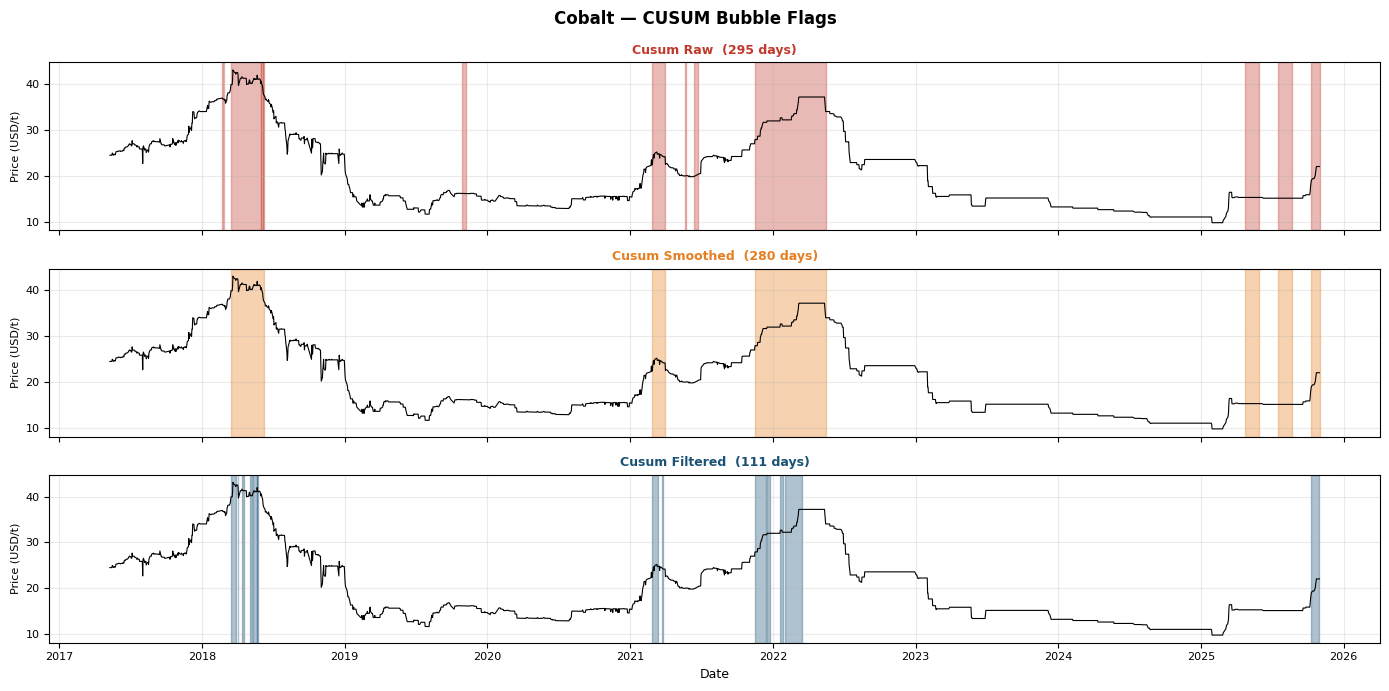

Saved → ../outputs/05_cusum_cobalt.png


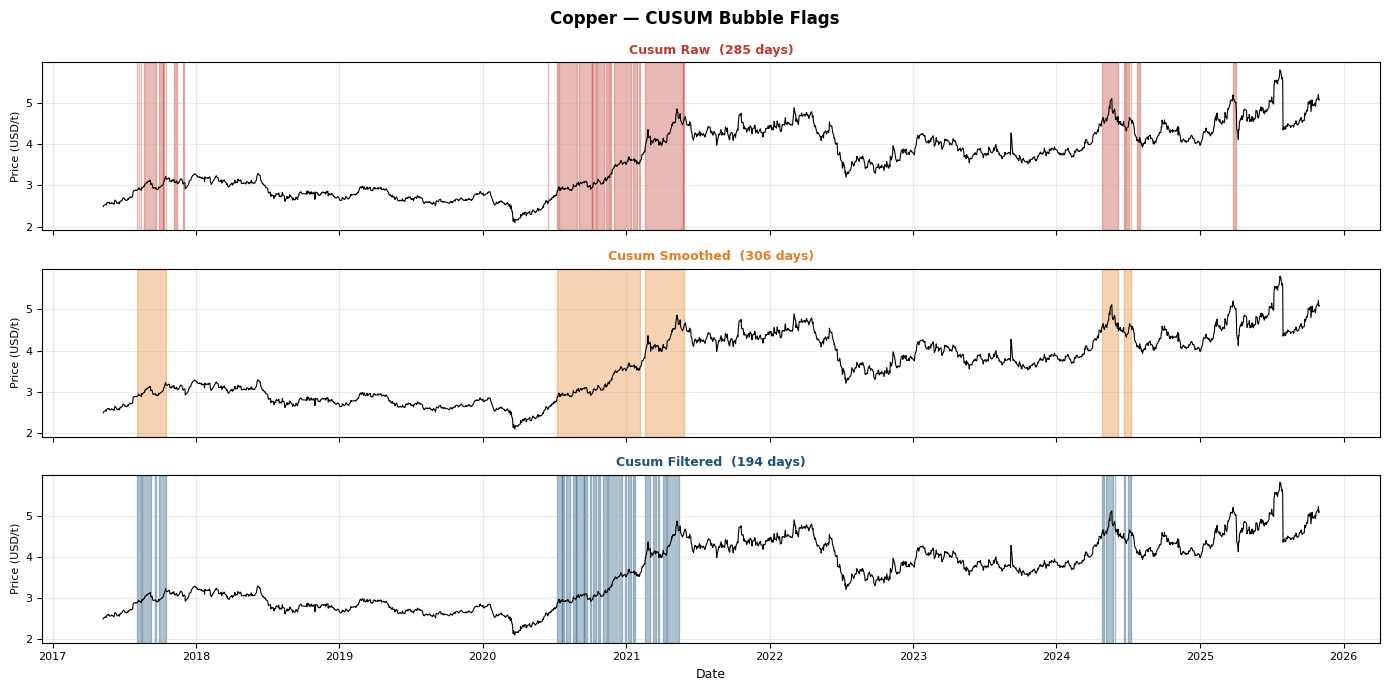

Saved → ../outputs/05_cusum_copper.png


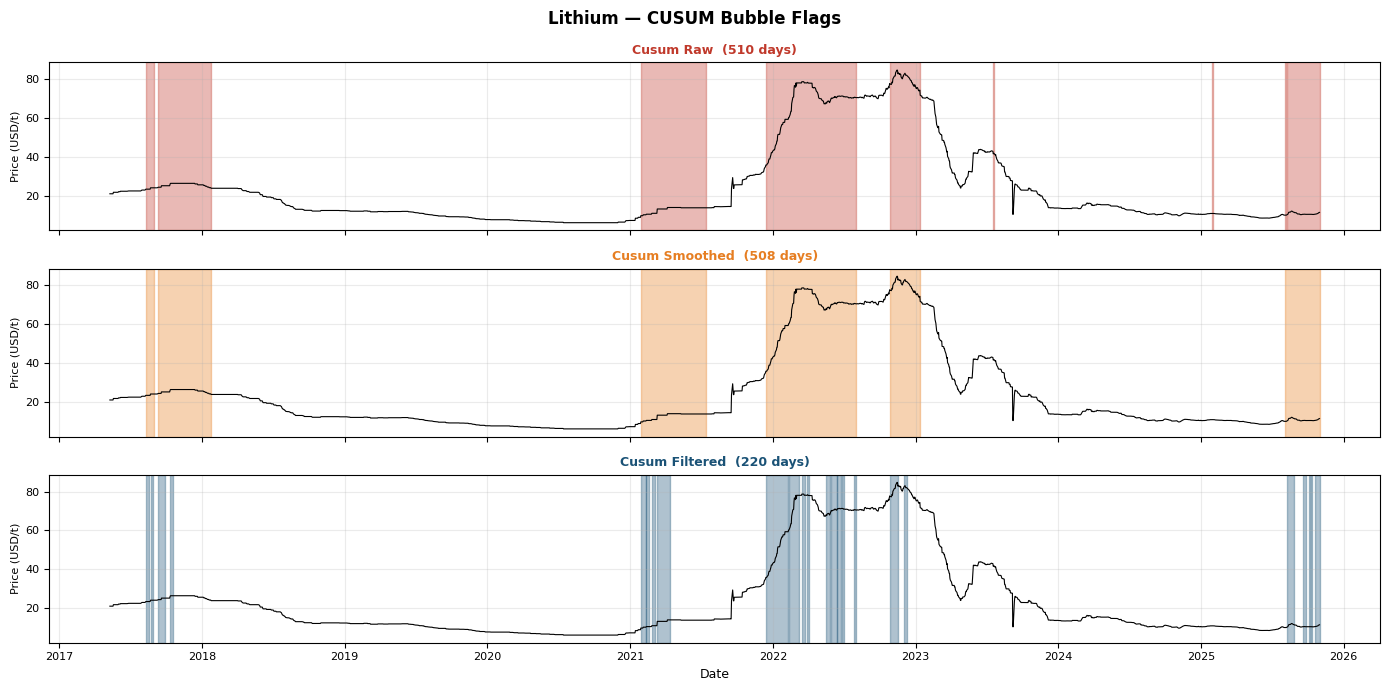

Saved → ../outputs/05_cusum_lithium.png


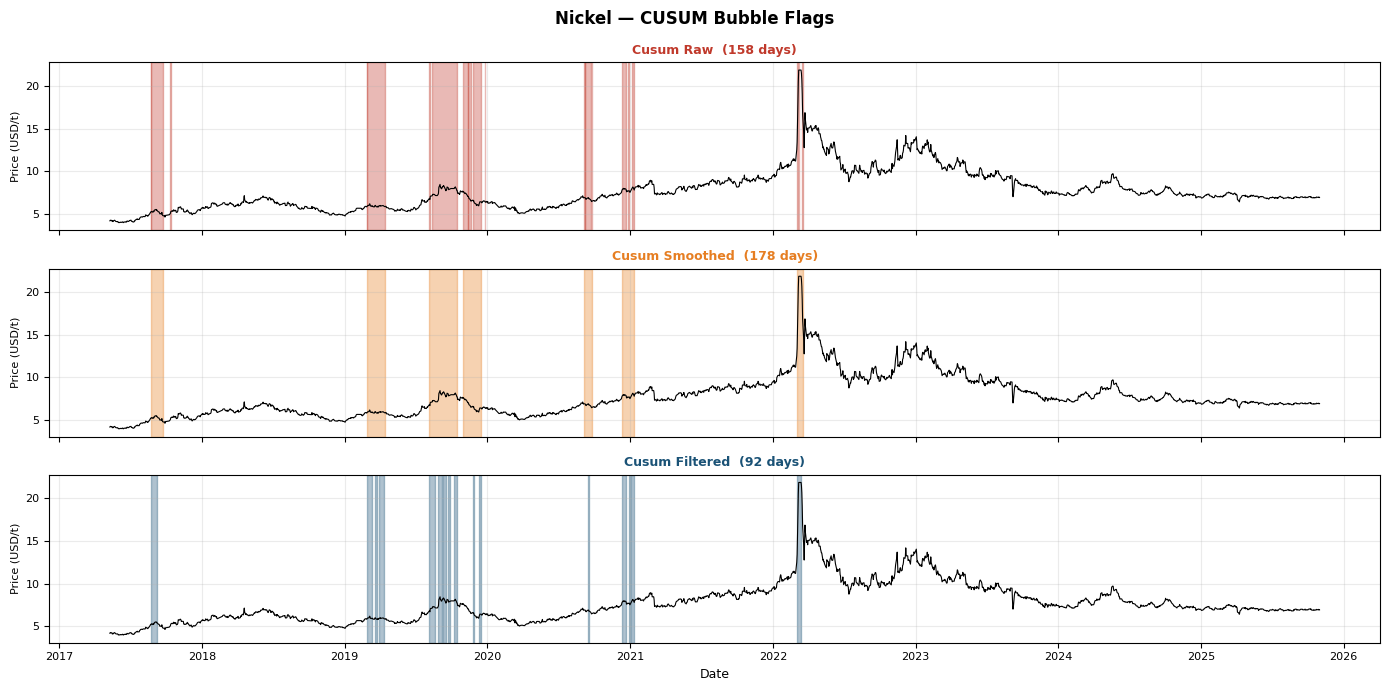

Saved → ../outputs/05_cusum_nickel.png


In [2]:
CUSUM_COLORS = {
    'cusum_raw':      '#c0392b',
    'cusum_smoothed': '#e67e22',
    'cusum_filtered': '#1a5276',
}

dates = df['Date']

for metal, col in METALS.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    for ax, cv in zip(axes, CUSUM_VARIANTS):
        ax.plot(dates, df[col], color='black', lw=0.8)
        flag = df[f'{col}_{cv}'].values
        color = CUSUM_COLORS[cv]
        in_b = False
        for i in range(len(flag)):
            if flag[i] == 1 and not in_b:
                s = dates.iloc[i]; in_b = True
            elif (flag[i] == 0 or i == len(flag) - 1) and in_b:
                ax.axvspan(s, dates.iloc[i], color=color, alpha=0.35)
                in_b = False
        ax.set_title(cv.replace('_', ' ').title() + f'  ({int(flag.sum())} days)',
                     fontsize=9, fontweight='bold', color=color)
        ax.set_ylabel('Price (USD/t)', fontsize=8)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.25)
    axes[-1].set_xlabel('Date', fontsize=9)
    plt.suptitle(f'{metal} — CUSUM Bubble Flags', fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_path = f'../outputs/05_cusum_{metal.lower()}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')


## 2. Method 1 — Cohen's Kappa (κ): Day-Level Agreement

For every combination of (metal × label variant × CUSUM variant) we compute κ.  
The primary reference is `cusum_filtered` (trend-filtered, closest analogue to GSADF/LPPLS labels).

**Landis & Koch (1977) benchmarks:**  
κ < 0.20 = slight · 0.21–0.40 = fair · 0.41–0.60 = moderate · 0.61–0.80 = substantial · >0.80 = near-perfect

In [3]:
def kappa_grade(k):
    if k < 0.20:  return 'slight'
    if k < 0.40:  return 'fair'
    if k < 0.60:  return 'moderate'
    if k < 0.80:  return 'substantial'
    return 'near-perfect'


rows = []
for metal, col in METALS.items():
    for cv in CUSUM_VARIANTS:
        ref = df[f'{col}_{cv}'].values.astype(int)
        for lv in LABEL_VARIANTS:
            label_col = f'{metal}_{lv}'
            if label_col not in df.columns:
                continue
            pred = df[label_col].values.astype(int)
            # cohen_kappa_score requires both classes present
            try:
                k = cohen_kappa_score(ref, pred)
            except Exception:
                k = np.nan
            rows.append({'Metal': metal, 'LabelVariant': lv, 'CusumVariant': cv,
                         'Kappa': round(k, 4)})

kappa_df = pd.DataFrame(rows)
kappa_df['Grade'] = kappa_df['Kappa'].apply(kappa_grade)

# ── Primary table: cusum_filtered reference ──────────────────────────────
primary = (kappa_df[kappa_df.CusumVariant == 'cusum_filtered']
           .pivot(index='LabelVariant', columns='Metal', values='Kappa')
           .reindex(LABEL_VARIANTS))

print('Cohen\'s Kappa  (reference = cusum_filtered)\n')
print(f'{"Variant":28s}', end='')
for m in METALS: print(f'  {m:10s}', end='')
print()
print('-' * (28 + 14 * len(METALS)))
for vname, row in primary.iterrows():
    print(f'{vname:28s}', end='')
    for m in METALS:
        v = row[m]
        g = kappa_grade(v) if not np.isnan(v) else '—'
        print(f'  {v:5.3f} ({g[:3]})', end='')
    print()

kappa_df.to_csv('../outputs/05_kappa_all.csv', index=False)
print(f'\nFull table → ../outputs/05_kappa_all.csv')


Cohen's Kappa  (reference = cusum_filtered)

Variant                       Cobalt      Copper      Lithium     Nickel    
------------------------------------------------------------------------------------
gsadf_ols                     0.259 (fai)  0.175 (sli)  0.411 (mod)  0.128 (sli)
gsadf_ols_period              0.259 (fai)  0.175 (sli)  0.411 (mod)  0.128 (sli)
gsadf_v1                      0.503 (mod)  0.230 (fai)  0.547 (mod)  0.326 (fai)
gsadf_v1_period               0.511 (mod)  0.218 (fai)  0.492 (mod)  0.326 (fai)
gsadf_updown                  0.266 (fai)  0.226 (fai)  0.108 (sli)  0.309 (fai)
gsadf_updown_period           0.270 (fai)  0.208 (fai)  0.106 (sli)  0.309 (fai)
lppls_0.20                    0.263 (fai)  0.203 (fai)  0.103 (sli)  0.108 (sli)
lppls_0.20_period             0.255 (fai)  0.150 (sli)  0.137 (sli)  0.118 (sli)
lppls_0.10                    0.344 (fai)  0.192 (sli)  0.262 (fai)  0.232 (fai)
lppls_0.10_period             0.349 (fai)  0.241 (fai)  0.230 (f

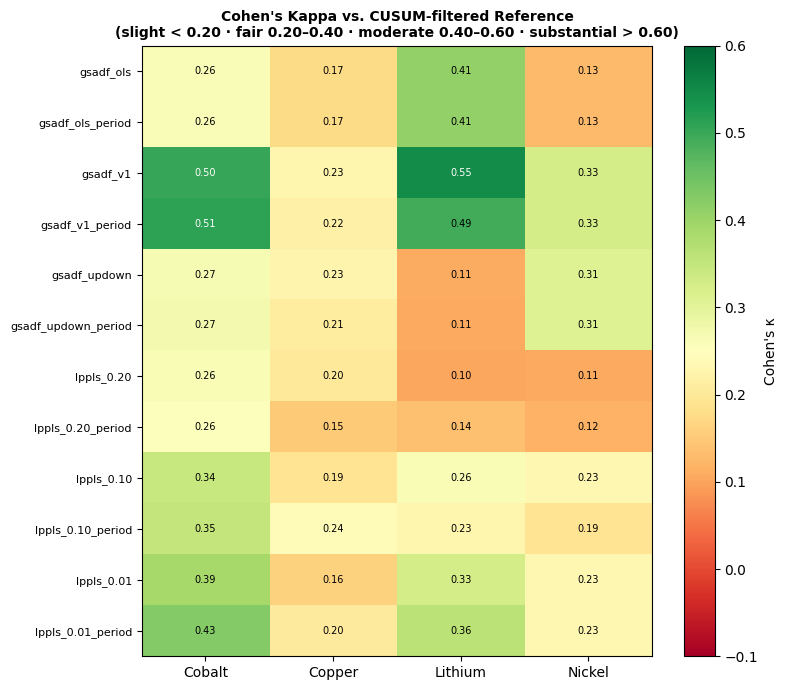

Saved → ../outputs/05_kappa_heatmap.png


In [4]:
# ── Heatmap: Kappa for primary reference (cusum_filtered) ────────────────
fig, ax = plt.subplots(figsize=(8, 7))
heat_data = primary.values.astype(float)
im = ax.imshow(heat_data, aspect='auto', cmap='RdYlGn', vmin=-0.1, vmax=0.6)
ax.set_xticks(range(len(METALS)))
ax.set_xticklabels(list(METALS.keys()), fontsize=10)
ax.set_yticks(range(len(LABEL_VARIANTS)))
ax.set_yticklabels(LABEL_VARIANTS, fontsize=8)
for i in range(len(LABEL_VARIANTS)):
    for j, m in enumerate(METALS):
        v = heat_data[i, j]
        txt = f'{v:.2f}' if not np.isnan(v) else '—'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                color='black' if 0.1 < v < 0.5 else 'white')
plt.colorbar(im, ax=ax, label="Cohen's κ")
ax.set_title("Cohen's Kappa vs. CUSUM-filtered Reference\n"
             "(slight < 0.20 · fair 0.20–0.40 · moderate 0.40–0.60 · substantial > 0.60)",
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_kappa_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → ../outputs/05_kappa_heatmap.png')


## 3. Method 2 — Temporal Jaccard Index: Episode-Level Overlap

$$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

$J = 1$ means perfect overlap of flagged dates; $J = 0$ means no shared flagged day.  
Computed for every (metal × label variant × CUSUM variant) pair over the full time series.

In [5]:
def temporal_jaccard(a: np.ndarray, b: np.ndarray) -> float:
    """Jaccard index over sets of flagged day indices."""
    sa = set(np.where(a == 1)[0])
    sb = set(np.where(b == 1)[0])
    union = sa | sb
    if not union:
        return np.nan
    return len(sa & sb) / len(union)


jacc_rows = []
for metal, col in METALS.items():
    for cv in CUSUM_VARIANTS:
        ref = df[f'{col}_{cv}'].values.astype(int)
        for lv in LABEL_VARIANTS:
            label_col = f'{metal}_{lv}'
            if label_col not in df.columns:
                continue
            pred = df[label_col].values.astype(int)
            j = temporal_jaccard(ref, pred)
            jacc_rows.append({'Metal': metal, 'LabelVariant': lv,
                               'CusumVariant': cv, 'Jaccard': round(j, 4)})

jacc_df = pd.DataFrame(jacc_rows)

# ── Primary table: cusum_filtered reference ──────────────────────────────
jacc_prim = (jacc_df[jacc_df.CusumVariant == 'cusum_filtered']
             .pivot(index='LabelVariant', columns='Metal', values='Jaccard')
             .reindex(LABEL_VARIANTS))

print('Temporal Jaccard Index  (reference = cusum_filtered)\n')
print(f'{"Variant":28s}', end='')
for m in METALS: print(f'  {m:8s}', end='')
print()
print('-' * (28 + 12 * len(METALS)))
for vname, row in jacc_prim.iterrows():
    print(f'{vname:28s}', end='')
    for m in METALS:
        v = row[m]
        print(f'  {v:6.3f}  ', end='')
    print()

jacc_df.to_csv('../outputs/05_jaccard_all.csv', index=False)
print(f'\nFull table → ../outputs/05_jaccard_all.csv')


Temporal Jaccard Index  (reference = cusum_filtered)

Variant                       Cobalt    Copper    Lithium   Nickel  
----------------------------------------------------------------------------
gsadf_ols                      0.177     0.106     0.327     0.073  
gsadf_ols_period               0.177     0.106     0.327     0.073  
gsadf_v1                       0.355     0.142     0.427     0.202  
gsadf_v1_period                0.362     0.133     0.384     0.202  
gsadf_updown                   0.188     0.142     0.149     0.192  
gsadf_updown_period            0.191     0.129     0.148     0.192  
lppls_0.20                     0.159     0.132     0.062     0.071  
lppls_0.20_period              0.153     0.100     0.081     0.075  
lppls_0.10                     0.224     0.140     0.172     0.156  
lppls_0.10_period              0.228     0.173     0.147     0.132  
lppls_0.01                     0.259     0.127     0.222     0.157  
lppls_0.01_period              0.293     

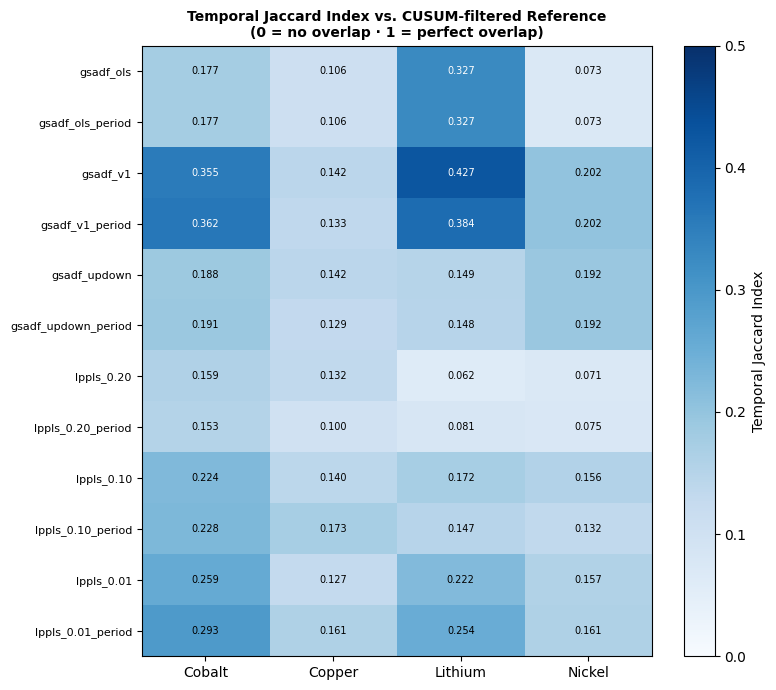

Saved → ../outputs/05_jaccard_heatmap.png


In [6]:
# ── Heatmap: Jaccard for primary reference (cusum_filtered) ──────────────
fig, ax = plt.subplots(figsize=(8, 7))
heat_j = jacc_prim.values.astype(float)
im = ax.imshow(heat_j, aspect='auto', cmap='Blues', vmin=0, vmax=0.5)
ax.set_xticks(range(len(METALS)))
ax.set_xticklabels(list(METALS.keys()), fontsize=10)
ax.set_yticks(range(len(LABEL_VARIANTS)))
ax.set_yticklabels(LABEL_VARIANTS, fontsize=8)
for i in range(len(LABEL_VARIANTS)):
    for j, m in enumerate(METALS):
        v = heat_j[i, j]
        txt = f'{v:.3f}' if not np.isnan(v) else '—'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                color='black' if v < 0.3 else 'white')
plt.colorbar(im, ax=ax, label='Temporal Jaccard Index')
ax.set_title('Temporal Jaccard Index vs. CUSUM-filtered Reference\n'
             '(0 = no overlap · 1 = perfect overlap)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_jaccard_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → ../outputs/05_jaccard_heatmap.png')


## 4. Combined Ranking: Best-Agreeing Label Variants

Average κ and Jaccard across all 4 metals (vs. `cusum_filtered`) to rank label variants by their overall concordance with the CUSUM reference.

In [7]:
filt_k = kappa_df[kappa_df.CusumVariant == 'cusum_filtered']
filt_j = jacc_df[jacc_df.CusumVariant == 'cusum_filtered']

mean_k = filt_k.groupby('LabelVariant')['Kappa'].mean().rename('Mean_Kappa')
mean_j = filt_j.groupby('LabelVariant')['Jaccard'].mean().rename('Mean_Jaccard')

ranking = pd.concat([mean_k, mean_j], axis=1).reindex(LABEL_VARIANTS)
# Composite score: equal weight
ranking['Composite'] = (ranking['Mean_Kappa'] + ranking['Mean_Jaccard']) / 2
ranking = ranking.sort_values('Composite', ascending=False)

print('Ranking by concordance with CUSUM-filtered (mean across 4 metals)\n')
print(f'{"Variant":28s}  {"Mean κ":>8s}  {"Mean J":>8s}  {"Composite":>10s}  {"κ Grade"}')
print('-' * 75)
for vname, row in ranking.iterrows():
    print(f'{vname:28s}  {row.Mean_Kappa:8.4f}  {row.Mean_Jaccard:8.4f}  '
          f'{row.Composite:10.4f}  {kappa_grade(row.Mean_Kappa)}')

ranking.to_csv('../outputs/05_ranking.csv')
print(f'\nSaved → ../outputs/05_ranking.csv')


Ranking by concordance with CUSUM-filtered (mean across 4 metals)

Variant                         Mean κ    Mean J   Composite  κ Grade
---------------------------------------------------------------------------
gsadf_v1                        0.4013    0.2817      0.3415  moderate
gsadf_v1_period                 0.3867    0.2703      0.3285  fair
lppls_0.01_period               0.3060    0.2172      0.2616  fair
lppls_0.01                      0.2771    0.1913      0.2342  fair
lppls_0.10                      0.2575    0.1731      0.2153  fair
lppls_0.10_period               0.2527    0.1699      0.2113  fair
gsadf_ols                       0.2432    0.1707      0.2069  fair
gsadf_ols_period                0.2432    0.1707      0.2069  fair
gsadf_updown                    0.2271    0.1679      0.1975  fair
gsadf_updown_period             0.2232    0.1651      0.1942  fair
lppls_0.20                      0.1690    0.1062      0.1376  slight
lppls_0.20_period               0.1650    0.

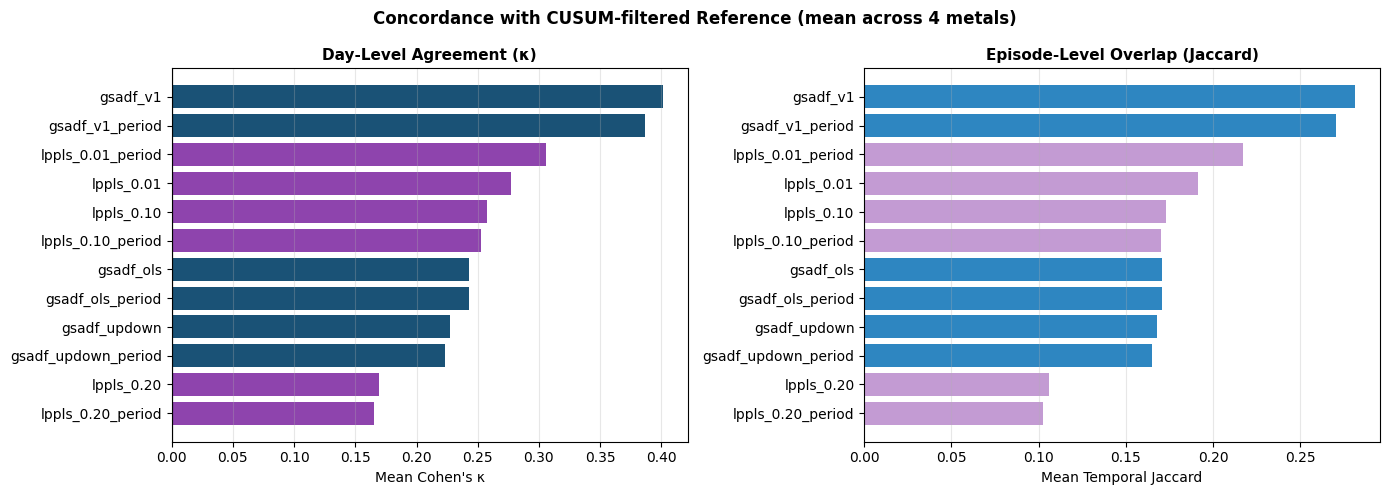

Saved → ../outputs/05_concordance_bars.png


In [8]:
# ── Bar chart: composite score by variant ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#1a5276' if 'gsadf' in v else
              '#17a589' if 'updown' in v else '#8e44ad'
              for v in ranking.index]

axes[0].barh(ranking.index, ranking['Mean_Kappa'], color=colors_bar)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel("Mean Cohen's κ", fontsize=10)
axes[0].set_title("Day-Level Agreement (κ)", fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(ranking.index, ranking['Mean_Jaccard'],
             color=[c.replace('1a5276', '2e86c1').replace('17a589', '27ae60')
                    .replace('8e44ad', 'c39bd3') for c in colors_bar])
axes[1].set_xlabel('Mean Temporal Jaccard', fontsize=10)
axes[1].set_title('Episode-Level Overlap (Jaccard)', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Concordance with CUSUM-filtered Reference (mean across 4 metals)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_concordance_bars.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → ../outputs/05_concordance_bars.png')


## 5. Side-by-Side Visual Comparison: Best Variant vs. CUSUM

For each metal, overlay the highest-κ label variant alongside the CUSUM-filtered reference on the same price chart.

Best-agreeing label variant per metal (vs cusum_filtered):
  Cobalt    : gsadf_v1_period  (κ = 0.511)
  Copper    : lppls_0.10_period  (κ = 0.241)
  Lithium   : gsadf_v1  (κ = 0.547)
  Nickel    : gsadf_v1_period  (κ = 0.326)


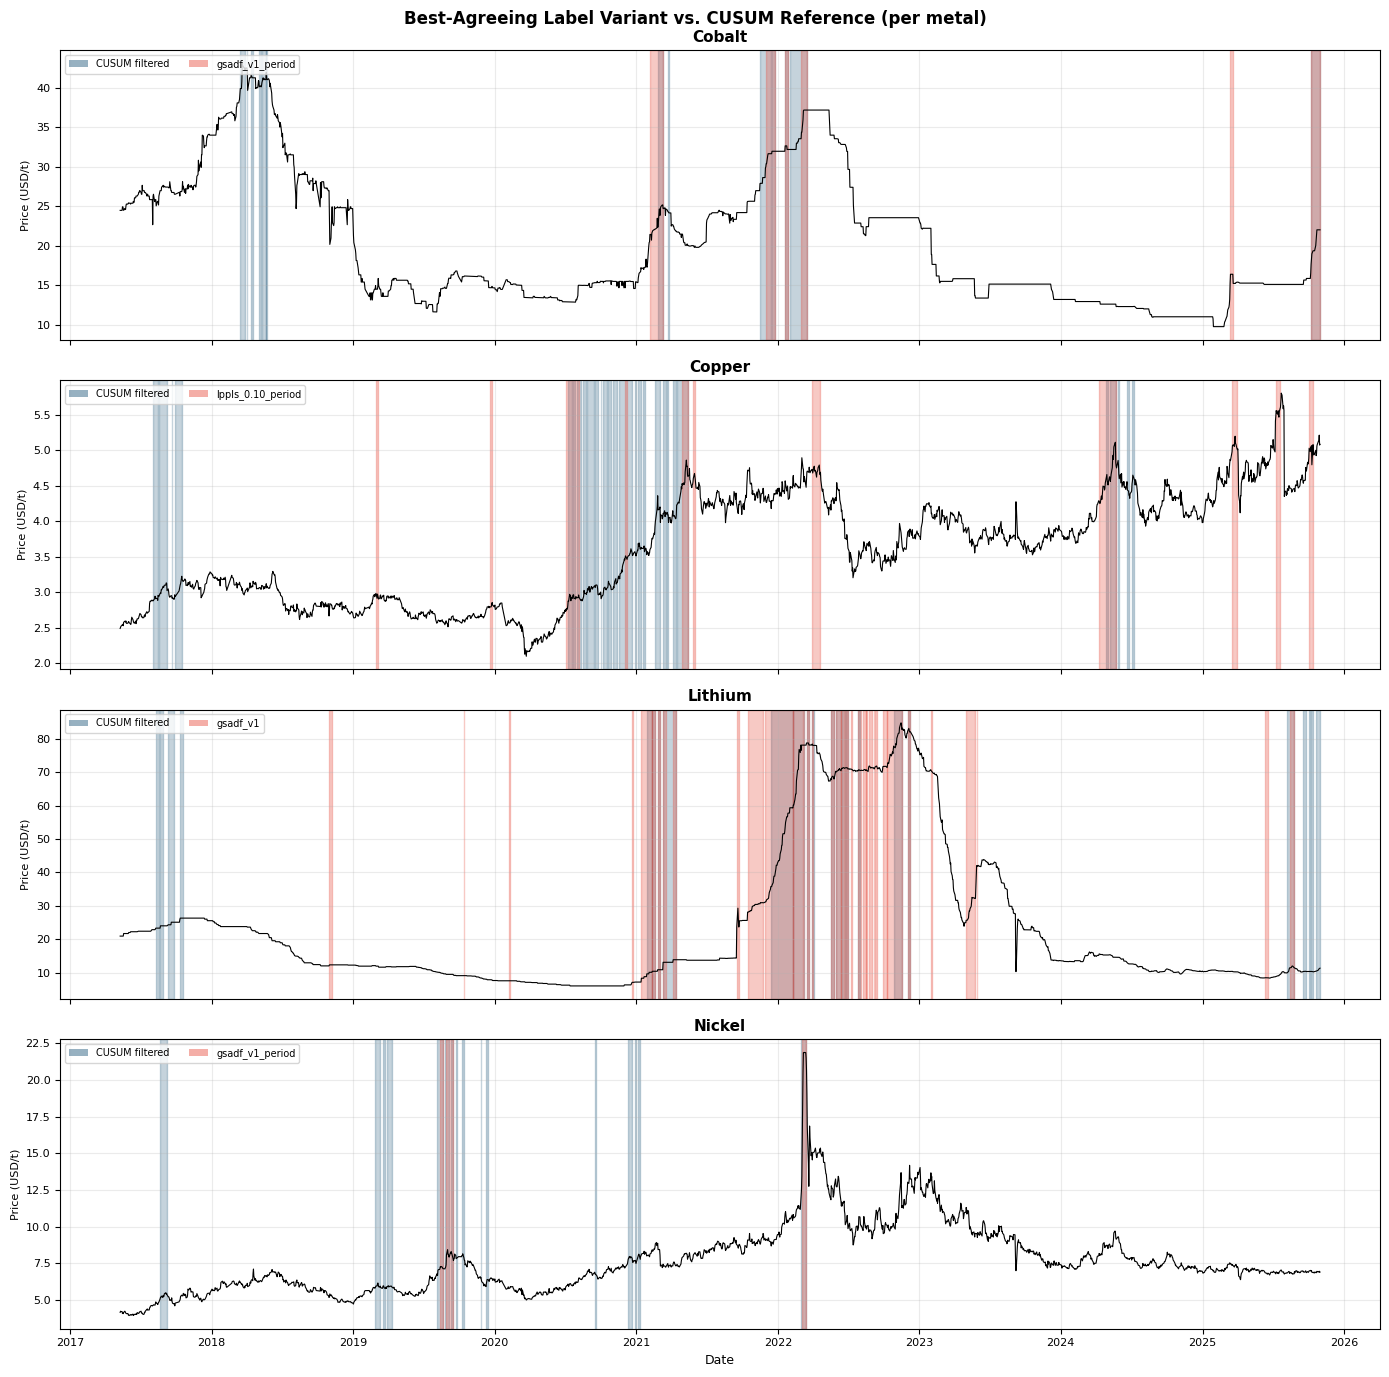

Saved → ../outputs/05_best_vs_cusum.png


In [9]:
# Best variant per metal by kappa vs cusum_filtered
best_per_metal = (filt_k.groupby(['Metal', 'LabelVariant'])['Kappa']
                  .mean().reset_index()
                  .sort_values('Kappa', ascending=False)
                  .groupby('Metal').first()['LabelVariant'])

print('Best-agreeing label variant per metal (vs cusum_filtered):')
for m, v in best_per_metal.items():
    k = filt_k[(filt_k.Metal == m) & (filt_k.LabelVariant == v)]['Kappa'].mean()
    print(f'  {m:10s}: {v}  (κ = {k:.3f})')

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, (metal, col) in zip(axes, METALS.items()):
    ax.plot(dates, df[col], color='black', lw=0.8, label='Price')

    # CUSUM reference (top strip)
    cusum_flag = df[f'{col}_cusum_filtered'].values
    in_b = False
    for i in range(len(cusum_flag)):
        if cusum_flag[i] == 1 and not in_b:
            s = dates.iloc[i]; in_b = True
        elif (cusum_flag[i] == 0 or i == len(cusum_flag) - 1) and in_b:
            ax.axvspan(s, dates.iloc[i], color='#1a5276', alpha=0.25,
                       label='CUSUM filtered' if in_b else '')
            in_b = False

    # Best label variant
    best_v = best_per_metal[metal]
    label_col = f'{metal}_{best_v}'
    if label_col in df.columns:
        pred_flag = df[label_col].values
        in_b = False
        for i in range(len(pred_flag)):
            if pred_flag[i] == 1 and not in_b:
                s = dates.iloc[i]; in_b = True
            elif (pred_flag[i] == 0 or i == len(pred_flag) - 1) and in_b:
                ax.axvspan(s, dates.iloc[i], color='#e74c3c', alpha=0.30,
                           label=best_v if in_b else '')
                in_b = False

    ax.set_title(metal, fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (USD/t)', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)

    handles = [
        plt.Rectangle((0, 0), 1, 1, fc='#1a5276', alpha=0.45),
        plt.Rectangle((0, 0), 1, 1, fc='#e74c3c', alpha=0.45),
    ]
    ax.legend(handles, ['CUSUM filtered', best_v],
              fontsize=7, loc='upper left', ncol=2)

axes[-1].set_xlabel('Date', fontsize=9)
plt.suptitle('Best-Agreeing Label Variant vs. CUSUM Reference (per metal)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_best_vs_cusum.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → ../outputs/05_best_vs_cusum.png')


## 6. Sensitivity: All Three CUSUM Variants

How stable are the κ and Jaccard rankings when the CUSUM reference changes from `filtered` → `smoothed` → `raw`?

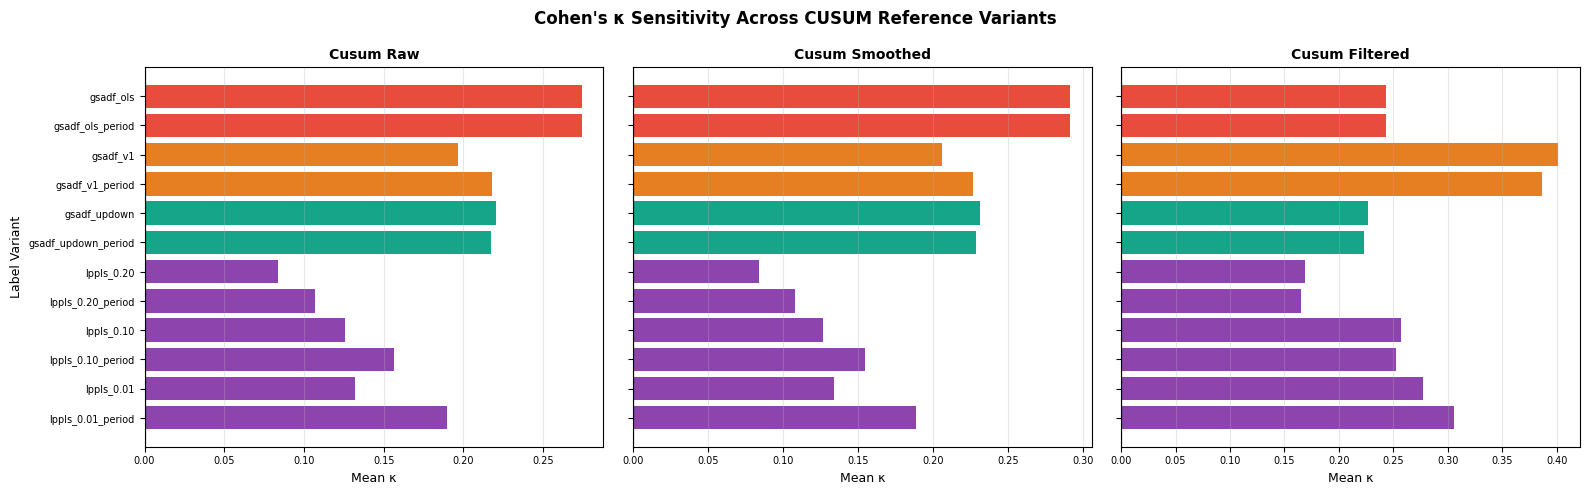

Saved → ../outputs/05_kappa_sensitivity.png

── Outputs written ──
  ../outputs/05_kappa_all.csv
  ../outputs/05_kappa_heatmap.png
  ../outputs/05_jaccard_all.csv
  ../outputs/05_jaccard_heatmap.png
  ../outputs/05_ranking.csv
  ../outputs/05_concordance_bars.png
  ../outputs/05_best_vs_cusum.png
  ../outputs/05_kappa_sensitivity.png
  ../outputs/05_cusum_{metal}.png  (×4)


: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, cv in zip(axes, CUSUM_VARIANTS):
    mean_k_cv = (kappa_df[kappa_df.CusumVariant == cv]
                 .groupby('LabelVariant')['Kappa'].mean()
                 .reindex(LABEL_VARIANTS))
    colors_s = ['#e74c3c' if 'ols' in v else
                '#e67e22' if 'v1' in v else
                '#17a589' if 'updown' in v else '#8e44ad'
                for v in mean_k_cv.index]
    ax.barh(mean_k_cv.index, mean_k_cv.values, color=colors_s)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel("Mean κ", fontsize=9)
    ax.set_title(cv.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Label Variant', fontsize=9)
plt.suptitle("Cohen's κ Sensitivity Across CUSUM Reference Variants",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_kappa_sensitivity.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → ../outputs/05_kappa_sensitivity.png')

print('\n── Outputs written ──')
print('  ../outputs/05_kappa_all.csv')
print('  ../outputs/05_kappa_heatmap.png')
print('  ../outputs/05_jaccard_all.csv')
print('  ../outputs/05_jaccard_heatmap.png')
print('  ../outputs/05_ranking.csv')
print('  ../outputs/05_concordance_bars.png')
print('  ../outputs/05_best_vs_cusum.png')
print('  ../outputs/05_kappa_sensitivity.png')
print('  ../outputs/05_cusum_{metal}.png  (×4)')
